# Preprocessing and Baseline Model

This notebook builds a first baseline model for diabetes risk prediction. The focus is on clean data splitting, basic preprocessing, and transparent evaluation using a logistic regression and a random forest classifier.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import joblib

sys.path.append(str(Path.cwd().parent / 'src'))
from data_loader import load_cdc_diabetes_data

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 6), 'figure.dpi': 100})
MODELS_DIR = Path.cwd().parent / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## Load data and train/test split

In [2]:
X, y, df = load_cdc_diabetes_data()

print('Dataset shape:', df.shape)
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

print('Target value counts:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('Train set:', X_train.shape, 'Test set:', X_test.shape)

Dataset shape: (253680, 22)
Feature shape: (253680, 21)
Target shape: (253680,)
Target value counts:
0    218334
1     35346
Name: Diabetes_binary, dtype: int64
Train set: (202944, 21) Test set: (50736, 21)


## Class imbalance check

The diabetes target is checked for class imbalance, which helps decide if additional model calibration or evaluation strategies are needed.

0    0.861
1    0.139
Name: Diabetes_binary, dtype: float64


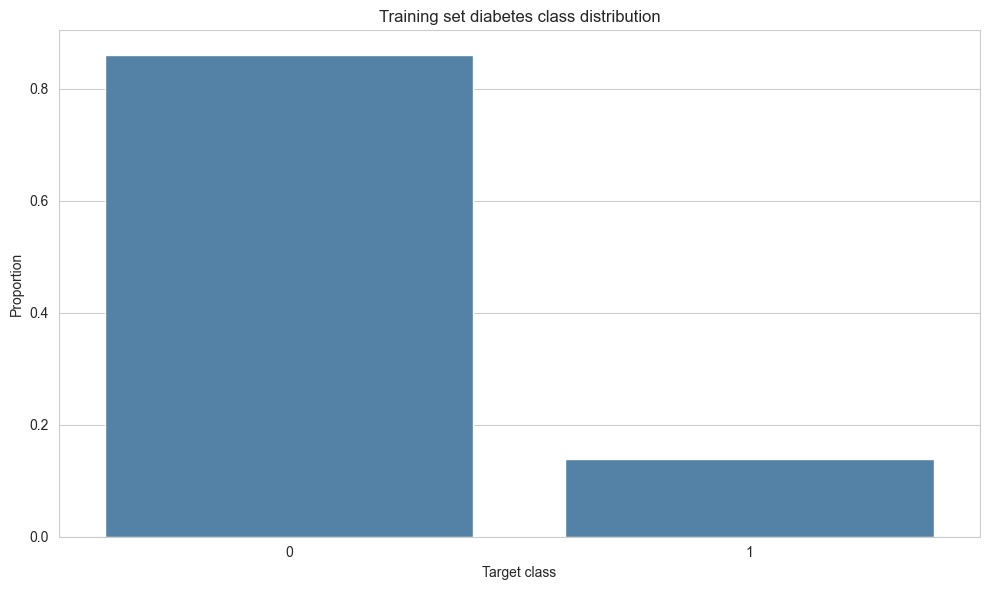

In [3]:
class_counts = y_train.value_counts(normalize=True).round(3)
print(class_counts)

plt.figure()
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, color='steelblue')
plt.title('Training set diabetes class distribution')
plt.xlabel('Target class')
plt.ylabel('Proportion')
plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'class_balance.png')
plt.show()

## Preprocessing pipeline

A simple preprocessing pipeline fills missing numeric values and scales numeric features. These steps are appropriate for baseline models and help keep the workflow reproducible.

In [4]:
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='passthrough'
)

print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numeric features: 21
Categorical features: 0


## Baseline models

Two baseline models are trained with the same preprocessing pipeline: logistic regression and random forest. These provide a starting point for later model comparison.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model),
    ])

    pipeline.fit(X_train, y_train)
    trained_models[model_name] = pipeline
    print(f'Trained {model_name}')

Trained Logistic Regression


Trained Random Forest


## Evaluation strategy

Baseline performance is assessed with multiple metrics because accuracy alone can be misleading when classes are imbalanced.

In [6]:
def evaluate_model(model, X_eval, y_eval):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1] if hasattr(model, 'predict_proba') else None
    results = {
        'accuracy': accuracy_score(y_eval, preds),
        'precision': precision_score(y_eval, preds, zero_division=0),
        'recall': recall_score(y_eval, preds, zero_division=0),
        'f1': f1_score(y_eval, preds, zero_division=0),
        'roc_auc': roc_auc_score(y_eval, probs) if probs is not None else None,
        'confusion_matrix': confusion_matrix(y_eval, preds),
    }
    return results

evaluation_summary = {}
for model_name, model in trained_models.items():
    evaluation_summary[model_name] = evaluate_model(model, X_test, y_test)

for model_name, metrics in evaluation_summary.items():
    print(f'### {model_name}')
    print('Accuracy:', round(metrics['accuracy'], 4))
    print('Precision:', round(metrics['precision'], 4))
    print('Recall:', round(metrics['recall'], 4))
    print('F1-score:', round(metrics['f1'], 4))
    print('ROC AUC:', round(metrics['roc_auc'], 4) if metrics['roc_auc'] is not None else 'N/A')
    print('Confusion matrix:')
    print(metrics["confusion_matrix"])
    print()

### Logistic Regression
Accuracy: 0.8621
Precision: 0.5164
Recall: 0.1584
F1-score: 0.2425
ROC AUC: 0.8192
Confusion matrix:
[[42618  1049]
 [ 5949  1120]]

### Random Forest
Accuracy: 0.8594
Precision: 0.488
Recall: 0.1791
F1-score: 0.262
ROC AUC: 0.7948
Confusion matrix:
[[42339  1328]
 [ 5803  1266]]



## Why accuracy is not enough

Accuracy can mask poor performance on the minority class when data are imbalanced. In a healthcare risk prediction task, recall and precision are especially important because false negatives and false positives may have different practical implications.

## Save baseline models

The trained baseline pipelines are saved for later comparison with improved models and interpretability analysis.

In [7]:
for model_name, model in trained_models.items():
    model_path = MODELS_DIR / (model_name.lower().replace(" ", "_") + "_baseline.joblib")
    joblib.dump(model, model_path)
    print(f"Saved {model_name} pipeline to {model_path}")

Saved Logistic Regression pipeline to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/models/logistic_regression_baseline.joblib


Saved Random Forest pipeline to /Users/paolaantonicoli/Desktop/healthcare-analytics-ml/healthcare-ai-ml/models/random_forest_baseline.joblib
